# Tablet-Side Extraction Validation

Validates `divide_tablet_photo` against `SURFACE_AT_LINE` ground truth annotations.

**Sections:**
1. Setup & load GT
2. Run `divide_tablet_photo` on all eligible fragments
3. IoU-based metrics at thresholds 0.70 / 0.80 / 0.85 / 0.90 / 0.95 / 0.975
4. Visualize fragments with missed detections at IoU=0.70
5. Generate Excel for manual review

## 1. Setup & load ground truth

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

sys.path.insert(0, str(Path('..').resolve()))
from data_processing.divide_photos import divide_tablet_photo

ANNOTATIONS_DIR = Path('/home/jebediahc/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations/annotations')
IMGS_DIR        = Path('/home/jebediahc/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations/imgs')
VIS_DIR         = Path('validation_visualizations')
VIS_DIR.mkdir(exist_ok=True)

SURFACE_LABEL  = 'SURFACE_AT_LINE'
IMG_EXTENSIONS = ['.jpg', '.jpeg', '.png']

random.seed(42)

In [2]:
def parse_annotation_file(filepath):
    entries = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 5:
                try:
                    x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                    label = parts[4].strip()
                    entries.append({'x': x, 'y': y, 'w': w, 'h': h, 'label': label})
                except ValueError:
                    pass
    return entries

def find_image(fragment_id):
    for ext in IMG_EXTENSIONS:
        p = IMGS_DIR / f"{fragment_id}{ext}"
        if p.exists():
            return p
    return None

# Load all GT data — only fragments with SURFACE_AT_LINE >= 1 and an image
gt_data = {}   # fragment_id -> list of SURFACE_AT_LINE boxes

for gt_file in sorted(ANNOTATIONS_DIR.glob('gt_*.txt')):
    fid = gt_file.stem[3:]  # strip 'gt_'
    entries = parse_annotation_file(gt_file)
    surface_boxes = [e for e in entries if e['label'] == SURFACE_LABEL]
    if surface_boxes and find_image(fid) is not None:
        gt_data[fid] = surface_boxes

print(f"Eligible fragments (SURFACE_AT_LINE >= 1 + image available): {len(gt_data)}")
dist = Counter(len(v) for v in gt_data.values())
print("GT side count distribution:")
for k in sorted(dist):
    print(f"  {k} side(s): {dist[k]} fragments")

Eligible fragments (SURFACE_AT_LINE >= 1 + image available): 530
GT side count distribution:
  1 side(s): 64 fragments
  2 side(s): 365 fragments
  3 side(s): 76 fragments
  4 side(s): 24 fragments
  7 side(s): 1 fragments


## 2. Run `divide_tablet_photo` on all eligible fragments

In [3]:
def run_divide(fragment_id):
    """Run divide_tablet_photo and return (img, predicted_coordinate_boxes)."""
    img_path = find_image(fragment_id)
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None
    try:
        _, pred_coords = divide_tablet_photo(
            img,
            return_coordinates=True,
            logging=False
        )
        return img, pred_coords
    except Exception as e:
        print(f"ERROR on {fragment_id}: {e}")
        return img, None

results = {}  # fragment_id -> {'gt': [...], 'pred': [...], 'img_shape': (h,w), 'error': bool}

for fid in tqdm(sorted(gt_data.keys()), desc='Running divide_tablet_photo'):
    img, pred_coords = run_divide(fid)
    if img is None:
        continue
    h, w = img.shape[:2]
    results[fid] = {
        'gt':        gt_data[fid],
        'pred':      pred_coords if pred_coords is not None else [],
        'img_shape': (h, w),
        'error':     pred_coords is None
    }

ok  = sum(1 for v in results.values() if not v['error'])
err = sum(1 for v in results.values() if v['error'])
print(f"Processed {ok} successfully, {err} errors")

Running divide_tablet_photo:   0%|          | 0/530 [00:00<?, ?it/s]

Running divide_tablet_photo: 100%|██████████| 530/530 [02:59<00:00,  2.96it/s]

Processed 530 successfully, 0 errors


## 3. IoU-based metrics

- **TP**: GT box matched by a prediction at IoU ≥ threshold  
- **FN**: GT box not matched (missed detection)  
- **FP**: Predicted box not matched to any GT box  
- **TN**: Not applicable in object detection  

> GT boxes may not cover all visible sides; FP counts may therefore be inflated.

In [4]:
def compute_iou(box_a, box_b):
    ax1, ay1 = box_a['x'], box_a['y']
    ax2, ay2 = ax1 + box_a['w'], ay1 + box_a['h']
    bx1, by1 = box_b['x'], box_b['y']
    bx2, by2 = bx1 + box_b['w'], by1 + box_b['h']
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    if ix2 <= ix1 or iy2 <= iy1:
        return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    union = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / union if union > 0 else 0.0


def match_boxes(gt_boxes, pred_boxes, iou_threshold):
    """Greedy matching. Returns (tp, fp, fn)."""
    if not gt_boxes and not pred_boxes:
        return 0, 0, 0
    if not pred_boxes:
        return 0, 0, len(gt_boxes)
    if not gt_boxes:
        return 0, len(pred_boxes), 0

    iou_mat = np.array([[compute_iou(g, p) for p in pred_boxes] for g in gt_boxes])
    matched_gt, matched_pred = set(), set()

    pairs = sorted(
        [(iou_mat[i, j], i, j)
         for i in range(len(gt_boxes))
         for j in range(len(pred_boxes))],
        reverse=True
    )
    for iou_val, gi, pi in pairs:
        if iou_val < iou_threshold:
            break
        if gi not in matched_gt and pi not in matched_pred:
            matched_gt.add(gi)
            matched_pred.add(pi)

    tp = len(matched_gt)
    return tp, len(pred_boxes) - len(matched_pred), len(gt_boxes) - tp


IOU_THRESHOLDS = [0.70, 0.80, 0.85, 0.90, 0.95, 0.975]

agg = {t: {'TP': 0, 'FP': 0, 'FN': 0} for t in IOU_THRESHOLDS}
per_fragment_metrics = []

for fid, data in results.items():
    if data['error']:
        continue
    row = {'fragment_id': fid,
           'gt_count':   len(data['gt']),
           'pred_count': len(data['pred'])}
    for t in IOU_THRESHOLDS:
        tp, fp, fn = match_boxes(data['gt'], data['pred'], t)
        agg[t]['TP'] += tp
        agg[t]['FP'] += fp
        agg[t]['FN'] += fn
        row[f'TP@{t}'] = tp
        row[f'FP@{t}'] = fp
        row[f'FN@{t}'] = fn
    per_fragment_metrics.append(row)

df_per_frag = pd.DataFrame(per_fragment_metrics)

# Summary table
summary_rows = []
for t in IOU_THRESHOLDS:
    tp, fp, fn = agg[t]['TP'], agg[t]['FP'], agg[t]['FN']
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else float('nan')
    summary_rows.append({
        'IoU Threshold': t,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': 'N/A',
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1':        round(f1,   4)
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

 IoU Threshold   TP   FP   FN  TN  Precision  Recall     F1
         0.700 1071 2892   54 N/A     0.2702  0.9520 0.4210
         0.800  985 2978  140 N/A     0.2485  0.8756 0.3872
         0.850  817 3146  308 N/A     0.2062  0.7262 0.3211
         0.900  458 3505  667 N/A     0.1156  0.4071 0.1800
         0.950   83 3880 1042 N/A     0.0209  0.0738 0.0326
         0.975    6 3957 1119 N/A     0.0015  0.0053 0.0024


Exact count match (pred == gt): 0/530 = 0.000

Breakdown by GT side count:
  GT=1: 0/64 exact  mean_pred=6.81
  GT=2: 0/365 exact  mean_pred=7.53
  GT=3: 0/76 exact  mean_pred=7.68
  GT=4: 0/24 exact  mean_pred=7.58
  GT=7: 0/1 exact  mean_pred=12.00


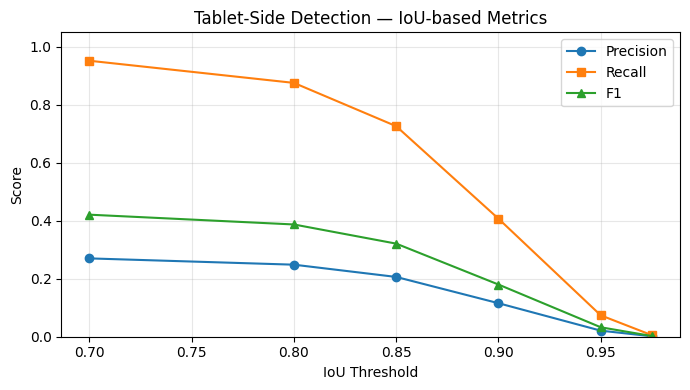

In [5]:
# Exact count match rate
exact = (df_per_frag['pred_count'] == df_per_frag['gt_count']).sum()
total = len(df_per_frag)
print(f"Exact count match (pred == gt): {exact}/{total} = {exact/total:.3f}")

print("\nBreakdown by GT side count:")
for k in sorted(df_per_frag['gt_count'].unique()):
    sub = df_per_frag[df_per_frag['gt_count'] == k]
    em = (sub['pred_count'] == k).sum()
    print(f"  GT={k}: {em}/{len(sub)} exact  mean_pred={sub['pred_count'].mean():.2f}")

# Plot
thresholds  = [r['IoU Threshold'] for r in summary_rows]
precisions  = [r['Precision']     for r in summary_rows]
recalls     = [r['Recall']        for r in summary_rows]
f1s         = [r['F1']            for r in summary_rows]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precisions, 'o-', label='Precision')
ax.plot(thresholds, recalls,    's-', label='Recall')
ax.plot(thresholds, f1s,        '^-', label='F1')
ax.set_xlabel('IoU Threshold')
ax.set_ylabel('Score')
ax.set_title('Tablet-Side Detection — IoU-based Metrics')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / 'iou_metrics_plot.png', dpi=150)
plt.show()

## 4. Visualize fragments with missed detections at IoU = 0.70

Show all (or up to `MAX_SHOW`) fragments where **FN > 0** at IoU=0.70,  
i.e. at least one annotated tablet side was not matched by any prediction.

In [6]:
MISS_THRESHOLD = 0.70
MAX_SHOW = 30   # cap for display

missed_fids = [
    r['fragment_id'] for r in per_fragment_metrics
    if r[f'FN@{MISS_THRESHOLD}'] > 0
]
print(f"Fragments with FN > 0 at IoU={MISS_THRESHOLD}: {len(missed_fids)}")

show_fids = missed_fids[:MAX_SHOW]

Fragments with FN > 0 at IoU=0.7: 46


In [7]:
def draw_boxes_on_image(img_rgb, gt_boxes, pred_boxes, scale=1.0):
    """Return a matplotlib Figure with GT (green) and Pred (red) boxes."""
    h, w = img_rgb.shape[:2]
    dw, dh = int(w * scale), int(h * scale)
    display = cv2.resize(img_rgb, (dw, dh))

    fig, ax = plt.subplots(figsize=(dw / 100, dh / 100))
    ax.imshow(display)
    ax.axis('off')

    for i, box in enumerate(gt_boxes):
        rect = patches.Rectangle(
            (box['x']*scale, box['y']*scale), box['w']*scale, box['h']*scale,
            linewidth=2, edgecolor='#00CC44', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(box['x']*scale+4, box['y']*scale+16, f'GT{i+1}',
                fontsize=7, color='#00CC44',
                bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))

    for i, box in enumerate(pred_boxes):
        rect = patches.Rectangle(
            (box['x']*scale, box['y']*scale), box['w']*scale, box['h']*scale,
            linewidth=2, edgecolor='#FF3333', facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
        ax.text(box['x']*scale+4, (box['y']+box['h'])*scale-6, f'P{i+1}',
                fontsize=7, color='#FF3333',
                bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))
    return fig


MISS_VIS_DIR = VIS_DIR / f'missed_detections_iou{MISS_THRESHOLD}'
MISS_VIS_DIR.mkdir(exist_ok=True)

for fid in tqdm(show_fids, desc='Saving missed-detection visualizations'):
    data    = results[fid]
    img_bgr = cv2.imread(str(find_image(fid)))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]
    scale   = min(1.0, 900 / w)

    row = next(r for r in per_fragment_metrics if r['fragment_id'] == fid)
    fn  = row[f'FN@{MISS_THRESHOLD}']
    fp  = row[f'FP@{MISS_THRESHOLD}']

    fig = draw_boxes_on_image(img_rgb, data['gt'], data['pred'], scale=scale)
    fig.suptitle(
        f"{fid} | GT={len(data['gt'])} Pred={len(data['pred'])} | FN={fn} FP={fp} @IoU={MISS_THRESHOLD}",
        fontsize=9
    )
    fig.savefig(MISS_VIS_DIR / f'{fid}.png', dpi=100, bbox_inches='tight')
    plt.close(fig)

print(f"Saved {len(show_fids)} visualizations → {MISS_VIS_DIR}/")

Saving missed-detection visualizations: 100%|██████████| 30/30 [00:14<00:00,  2.02it/s]

Saved 30 visualizations → validation_visualizations/missed_detections_iou0.7/


In [ ]:
# Display a grid of the first 6 missed-detection samples inline
preview = show_fids[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fid in zip(axes.flatten(), preview):
    p = MISS_VIS_DIR / f'{fid}.png'
    if p.exists():
        ax.imshow(plt.imread(str(p)))
    ax.axis('off')
plt.suptitle(f'Missed detections at IoU={MISS_THRESHOLD} — first {len(preview)} samples  '
             f'(green=GT, red-dashed=Pred)', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Generate Excel for manual review

100 randomly sampled fragments.  
Manually open each image, run the algorithm (or use the saved vis), then fill in:
- **True Total Sides** — how many sides you actually see in the photo
- **Missed Detections** — sides visible but not detected
- **False Detections** — detected regions that are not real sides

In [9]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side as XlSide
from openpyxl.utils import get_column_letter

EXCEL_OUT = Path('tablet_side_manual_review.xlsx')

# ---------- Sample 100 fragments (stratified by gt_count) ----------
eligible = [r for r in per_fragment_metrics if not results[r['fragment_id']]['error']]

groups_by_gt = defaultdict(list)
for r in eligible:
    groups_by_gt[r['gt_count']].append(r['fragment_id'])

n_sample = min(100, len(eligible))
sample_ids = []
for k in sorted(groups_by_gt):
    group = groups_by_gt[k]
    n = max(1, round(len(group) / len(eligible) * n_sample))
    sample_ids.extend(random.sample(group, min(n, len(group))))

remaining = [r['fragment_id'] for r in eligible if r['fragment_id'] not in set(sample_ids)]
random.shuffle(remaining)
sample_ids = (sample_ids + remaining)[:n_sample]
random.shuffle(sample_ids)
print(f"Selected {len(sample_ids)} fragments for manual review")

# ---------- Build workbook ----------
wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'Manual Review'

HEADERS = [
    '#',
    'Fragment ID',
    'Image Path',
    'Predicted\nSides',
    'True Total\nSides (manual)',
    'Missed\nDetections (FN)',
    'False\nDetections (FP)',
    'Notes',
]
COL_WIDTHS = [5, 22, 55, 10, 16, 16, 16, 35]

hdr_fill   = PatternFill('solid', fgColor='1F4E79')
hdr_font   = Font(bold=True, color='FFFFFF', size=10)
c_align    = Alignment(horizontal='center', vertical='center', wrap_text=True)
l_align    = Alignment(horizontal='left',   vertical='center', wrap_text=True)
border     = Border(
    left=XlSide(style='thin'), right=XlSide(style='thin'),
    top=XlSide(style='thin'),  bottom=XlSide(style='thin')
)
alt_fill   = PatternFill('solid', fgColor='DCE6F1')

for ci, (hdr, wid) in enumerate(zip(HEADERS, COL_WIDTHS), 1):
    cell = ws.cell(row=1, column=ci, value=hdr)
    cell.font      = hdr_font
    cell.fill      = hdr_fill
    cell.alignment = c_align
    cell.border    = border
    ws.column_dimensions[get_column_letter(ci)].width = wid
ws.row_dimensions[1].height = 36

frag_map = {r['fragment_id']: r for r in per_fragment_metrics}

for ri, fid in enumerate(sample_ids, start=2):
    m         = frag_map[fid]
    img_path  = str(find_image(fid))
    row_data  = [
        ri - 1,
        fid,
        img_path,
        m['pred_count'],
        '',   # True Total Sides — fill manually
        '',   # Missed Detections — fill manually
        '',   # False Detections  — fill manually
        '',   # Notes
    ]
    use_alt = (ri % 2 == 0)
    for ci, val in enumerate(row_data, 1):
        cell = ws.cell(row=ri, column=ci, value=val)
        cell.border    = border
        cell.alignment = l_align if ci in (3, 8) else c_align
        if use_alt:
            cell.fill = alt_fill
    ws.row_dimensions[ri].height = 18

ws.freeze_panes = 'A2'

# ---------- Instructions sheet ----------
ws2 = wb.create_sheet('Instructions')
ws2.column_dimensions['A'].width = 80
lines = [
    ('Tablet-Side Extraction — Manual Review Instructions', True),
    ('', False),
    ('Purpose', True),
    ('  Validate divide_tablet_photo by visual inspection, independent of GT annotations.', False),
    ('', False),
    ('How to review each row', True),
    ('  1. Open the image at the path in column C.', False),
    ('  2. Run divide_tablet_photo on it (or inspect saved visualizations).', False),
    ('  3. Fill in column E  — True Total Sides: how many tablet sides are visible in the photo.', False),
    ('  4. Fill in column F  — Missed Detections: sides visible but NOT detected (FN).', False),
    ('  5. Fill in column G  — False Detections: detected regions that are NOT real sides (FP).', False),
    ('  6. Optional: add any observations in column H (Notes).', False),
    ('', False),
    ('Notes', True),
    ('  - IoU is NOT applied here; judge by visual appearance only.', False),
    ('  - "Correct" means each visible side is its own separate crop,', False),
    ('    no side split across multiple crops, no two sides merged.', False),
    ('  - Column D (Predicted Sides) is pre-filled from the algorithm output.', False),
]
for i, (text, bold) in enumerate(lines, 1):
    cell = ws2.cell(row=i, column=1, value=text)
    cell.font      = Font(bold=bold, size=10)
    cell.alignment = l_align

wb.save(EXCEL_OUT)
print(f"Saved: {EXCEL_OUT}")

Selected 100 fragments for manual review
Saved: tablet_side_manual_review.xlsx
